# Load Stage-2 NLL Model And Raw Series

This notebook does two things:

1. Load a trained Stage-2 heteroscedastic penetration model from a run directory.
2. Load aligned raw penetration series (`cdf`, `bw_x`, `bw_polar`) from `MLP/synthetic_data/*/<source>/series_wide_clean`.

If `series_wide_clean` files do not exist yet, the notebook falls back to `series_clean` long-format CSVs and pivots them into wide format on the fly.

## Setup And Artifact Loading

The first block imports the notebook dependencies, resolves the Stage-2 run directory, and restores three artifacts from disk:

- the trained heteroscedastic regression model
- the run config used during training
- the feature-scaler state used to normalize static inputs

This keeps the notebook anchored to one concrete training run before any raw-series processing starts.


In [35]:
RUN_FULL_REFINEMENT = True

In [36]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path(r"C:\Users\Jiang\Documents\Mie_Postprocessing_Py")
MLP_ROOT = PROJECT_ROOT / "MLP"
if str(MLP_ROOT) not in sys.path:
    sys.path.insert(0, str(MLP_ROOT))

from toy_inference_from_run import choose_device, load_run_artifacts

SYNTHETIC_ROOT = MLP_ROOT / "synthetic_data"
RUN_DIR = MLP_ROOT / "runs_mlp" / "stage2_NLL_penetration_20260317_194155"
SERIES_SPLIT = "clean"  # clean | all
SOURCES = ["cdf", "bw_x", "bw_polar"]
BATCH_SIZE = 16
DEVICE = choose_device("auto")

COMMON_META_COLS = [
    "plumes",
    "diameter_mm",
    "umbrella_angle_deg",
    "fps",
    "chamber_pressure_bar",
    "injection_duration_us",
    "injection_pressure_bar",
    "control_backpressure_bar",
]
MERGE_KEYS = ["experiment_name", "file_path", "file_name", "file_stem", "plume_idx"]


In [37]:
model, train_config, scaler_state, model_path = load_run_artifacts(RUN_DIR, DEVICE)
print(f"Run dir: {RUN_DIR}")
print(f"Model path: {model_path}")
print(f"Device: {DEVICE}")
print(f"Feature columns: {train_config['feature_columns']}")
print(model)


Run dir: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\stage2_NLL_penetration_20260317_194155
Model path: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\stage2_NLL_penetration_20260317_194155\best_model_stage1.pt
Device: cuda
Feature columns: ['time_norm_0_5ms', 'tilt_angle_radian_z', 'plumes_z', 'diameter_mm_z', 'injection_duration_us_z', 'log_injection_pressure_bar_z', 'log_chamber_pressure_bar_z', 'log_delta_pressure_bar_z', 'control_backpressure_bar_z']
PenetrationMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.8, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.8, inplace=False)
    (8): Linear(in_features=512, out_features=128, bias=True)
    (9): LayerNorm

## Load And Normalize Raw Series Tables

The next blocks load aligned raw penetration series exported by `fit_raw_data.py`.

For each source (`cdf`, `bw_x`, `bw_polar`), the notebook prefers `series_wide_clean` so that one row already corresponds to one `(file, plume)` sample. If only long-format files exist, it rebuilds a wide table on the fly.

After that, all three sources are merged on shared sample keys so we can build one synchronized multi-channel view of the same plume trajectory.


In [38]:
def build_wide_from_long(series_df: pd.DataFrame) -> pd.DataFrame:
    if series_df.empty:
        return pd.DataFrame(columns=MERGE_KEYS + COMMON_META_COLS + ["delay_frames_raw", "delay_frames_used", "delay_source", "seq_len"])

    df = series_df.copy()
    key_cols = ["file_path", "file_name", "file_stem", "plume_idx"]

    if "frame_pos" not in df.columns:
        df = df.sort_values(key_cols + ["time_ms"])
        df["frame_pos"] = df.groupby(key_cols, dropna=False).cumcount()

    base = (
        df.loc[:, key_cols + ["frame_pos", "delay_frames_raw", "delay_frames_used", "delay_source"]]
        .sort_values(key_cols + ["frame_pos"])
        .groupby(key_cols, dropna=False)
        .agg(
            delay_frames_raw=("delay_frames_raw", "first"),
            delay_frames_used=("delay_frames_used", "first"),
            delay_source=("delay_source", "first"),
            seq_len=("frame_pos", "count"),
        )
        .reset_index()
    )

    time_wide = (
        df.pivot_table(index=key_cols, columns="frame_pos", values="time_ms", aggfunc="first")
        .sort_index(axis=1)
        .rename(columns=lambda c: f"time_ms_{int(c):03d}")
        .reset_index()
    )
    pen_wide = (
        df.pivot_table(index=key_cols, columns="frame_pos", values="penetration_mm", aggfunc="first")
        .sort_index(axis=1)
        .rename(columns=lambda c: f"penetration_mm_{int(c):03d}")
        .reset_index()
    )

    extra_cols = [
        col for col in df.columns
        if col not in key_cols + ["frame_pos", "time_s", "time_ms", "penetration_mm"]
    ]
    extra = df.loc[:, key_cols + extra_cols].drop_duplicates(key_cols)

    return base.merge(extra, on=key_cols, how="left").merge(time_wide, on=key_cols, how="left").merge(pen_wide, on=key_cols, how="left")


def split_dir_names(split: str) -> tuple[str, str]:
    if split == "clean":
        return "series_wide_clean", "series_clean"
    if split == "all":
        return "series_wide_all", "series_all"
    raise ValueError(f"Unsupported split: {split}")


def load_source_table(source: str, split: str = "clean") -> pd.DataFrame:
    wide_dir_name, long_dir_name = split_dir_names(split)
    frames: list[pd.DataFrame] = []

    for experiment_dir in sorted(SYNTHETIC_ROOT.iterdir()):
        if not experiment_dir.is_dir():
            continue

        source_dir = experiment_dir / source
        if not source_dir.exists():
            continue

        wide_files = sorted((source_dir / wide_dir_name).glob("*.csv")) if (source_dir / wide_dir_name).exists() else []
        if wide_files:
            for path in wide_files:
                df = pd.read_csv(path)
                df.insert(0, "experiment_name", experiment_dir.name)
                frames.append(df)
            continue

        long_files = sorted((source_dir / long_dir_name).glob("*.csv")) if (source_dir / long_dir_name).exists() else []
        for path in long_files:
            df_long = pd.read_csv(path)
            df_wide = build_wide_from_long(df_long)
            df_wide.insert(0, "experiment_name", experiment_dir.name)
            frames.append(df_wide)

    if not frames:
        raise FileNotFoundError(
            f"No raw series files found for source='{source}', split='{split}'. "
            "Run fit_raw_data.py first to populate synthetic_data outputs."
        )

    return pd.concat(frames, ignore_index=True, sort=False)


def rename_source_specific_columns(df: pd.DataFrame, source: str, keep_common_meta: bool) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    for col in df.columns:
        if col in MERGE_KEYS:
            continue
        if keep_common_meta and col in COMMON_META_COLS:
            continue
        rename_map[col] = f"{source}__{col}"
    return df.rename(columns=rename_map)


def merge_source_tables(source_tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    merged = None
    for idx, source in enumerate(SOURCES):
        table = source_tables[source]
        table = rename_source_specific_columns(table, source, keep_common_meta=(idx == 0))
        if merged is None:
            merged = table
        else:
            merged = merged.merge(table, on=MERGE_KEYS, how="inner")
    if merged is None:
        raise ValueError("No source tables to merge.")
    return merged


def prefixed_columns(df: pd.DataFrame, prefix: str) -> list[str]:
    cols = [c for c in df.columns if c.startswith(prefix)]
    cols.sort(key=lambda name: int(name.rsplit("_", 1)[1]))
    return cols


def available_frame_ids(df: pd.DataFrame, prefix: str) -> list[int]:
    return [int(col.rsplit("_", 1)[1]) for col in prefixed_columns(df, prefix)]


def extract_prefixed_matrix(df: pd.DataFrame, prefix: str, frame_ids: list[int] | None = None) -> np.ndarray:
    if frame_ids is None:
        cols = prefixed_columns(df, prefix)
        if not cols:
            return np.empty((len(df), 0), dtype=np.float32)
        return df.loc[:, cols].to_numpy(dtype=np.float32)

    cols = []
    for frame_id in frame_ids:
        col = f"{prefix}{frame_id:03d}"
        if col in df.columns:
            cols.append(df[col].to_numpy(dtype=np.float32))
        else:
            cols.append(np.full(len(df), np.nan, dtype=np.float32))
    if not cols:
        return np.empty((len(df), 0), dtype=np.float32)
    return np.column_stack(cols).astype(np.float32)


class RawSeriesDataset(Dataset):
    def __init__(self, series: np.ndarray, mask: np.ndarray, time_ms: np.ndarray, meta: pd.DataFrame):
        self.series = torch.as_tensor(series, dtype=torch.float32)
        self.mask = torch.as_tensor(mask, dtype=torch.bool)
        self.time_ms = torch.as_tensor(time_ms, dtype=torch.float32)
        self.meta = meta.reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.meta)

    def __getitem__(self, idx: int):
        return {
            "series": self.series[idx],
            "mask": self.mask[idx],
            "time_ms": self.time_ms[idx],
            "meta": self.meta.iloc[idx].to_dict(),
        }


In [39]:
source_tables = {source: load_source_table(source, split=SERIES_SPLIT) for source in SOURCES}
for source, table in source_tables.items():
    print(source, table.shape)

raw_series_df = merge_source_tables(source_tables)
print("merged shape:", raw_series_df.shape)
raw_series_df.head()


cdf (21675, 145)
bw_x (21635, 151)
bw_polar (19952, 143)
merged shape: (15633, 429)


,experiment_name,file_path,file_name,file_stem,plume_idx,cdf__delay_frames_raw,cdf__delay_frames_used,cdf__delay_source,cdf__seq_len,plumes,...,bw_polar__penetration_mm_054,bw_polar__penetration_mm_055,bw_polar__penetration_mm_056,bw_polar__penetration_mm_057,bw_polar__penetration_mm_058,bw_polar__penetration_mm_059,bw_polar__penetration_mm_060,bw_polar__penetration_mm_061,bw_polar__penetration_mm_062,bw_polar__penetration_mm_063
0,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,0,17.0,17.0,area,21,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,1,17.0,17.0,area,21,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,3,17.0,17.0,area,26,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,4,17.0,17.0,area,28,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,5,18.0,18.0,area,29,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
all_frame_ids = sorted({
    frame_id
    for source in SOURCES
    for frame_id in available_frame_ids(raw_series_df, f"{source}__penetration_mm_")
})

series_stack = np.stack(
    [extract_prefixed_matrix(raw_series_df, f"{source}__penetration_mm_", all_frame_ids) for source in SOURCES],
    axis=-1,
)
time_stack = np.stack(
    [extract_prefixed_matrix(raw_series_df, f"{source}__time_ms_", all_frame_ids) for source in SOURCES],
    axis=-1,
)

mask_stack = np.isfinite(series_stack)
series_tensor = np.nan_to_num(series_stack, nan=0.0).astype(np.float32)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    time_ms_tensor = np.nanmean(np.where(np.isfinite(time_stack), time_stack, np.nan), axis=-1).astype(np.float32)

meta_cols = MERGE_KEYS + COMMON_META_COLS + [
    "cdf__delay_frames_raw",
    "cdf__delay_frames_used",
    "cdf__delay_source",
    "cdf__seq_len",
    "bw_x__delay_frames_raw",
    "bw_x__delay_frames_used",
    "bw_x__delay_source",
    "bw_x__seq_len",
    "bw_polar__delay_frames_raw",
    "bw_polar__delay_frames_used",
    "bw_polar__delay_source",
    "bw_polar__seq_len",
]
meta_df = raw_series_df.loc[:, [c for c in meta_cols if c in raw_series_df.columns]].copy()

dataset = RawSeriesDataset(series_tensor, mask_stack, time_ms_tensor, meta_df)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

print("series_tensor shape:", series_tensor.shape)  # [N, T, 3]
print("mask_stack shape:", mask_stack.shape)        # [N, T, 3]
print("time_ms_tensor shape:", time_ms_tensor.shape)  # [N, T]
print("dataset size:", len(dataset))


series_tensor shape: (15633, 67, 3)
mask_stack shape: (15633, 67, 3)
time_ms_tensor shape: (15633, 67)
dataset size: 15633


## Tensorization For Sequence Use

This section converts the merged wide tables into tensor-friendly arrays:

- `series_tensor`: penetration values with shape `[N, T, C]`
- `mask_stack`: validity mask with the same shape
- `time_ms_tensor`: aligned time grid per sample

A lightweight `Dataset` / `DataLoader` wrapper is then built so the same notebook can be used either for inspection or as the start of a new sequence-model training pipeline.


## CDF Regime Labeling

The Stage-2 run is kept for model loading, but the regime labeling below uses **raw CDF only** as the observation source.

We bucket time into `0.1 ms` bins over `0~5 ms`, then classify each bin inside one operating-condition group into three regimes:

- `raw_reliable`: raw CDF coverage is still near the group peak and is trusted as the main supervision source.
- `raw_uncertain`: coverage has clearly started to fall; keep the regime tag, but this region is the first candidate for teacher-assisted supervision later.
- `teacher_only`: raw coverage has become too sparse; keep the bin for alignment and metadata, but do not treat raw observations there as strong direct supervision.

The rule is intentionally coverage-driven rather than value-driven, because the practical issue here is not just label magnitude noise but the **time-dependent disappearance of usable raw observations**.


In [41]:
BIN_MS = 0.1
TIME_MAX_MS = 5.0
N_BINS = int(TIME_MAX_MS / BIN_MS)

REGIME_GROUP_COLS = [
    "experiment_name",
    "plumes",
    "diameter_mm",
    "umbrella_angle_deg",
    "fps",
    "chamber_pressure_bar",
    "injection_duration_us",
    "injection_pressure_bar",
    "control_backpressure_bar",
]
CDF_SAMPLE_ID_COLS = ["experiment_name", "file_path", "plume_idx"]

UNCERTAIN_RATIO = 0.7
TEACHER_RATIO = 0.2
TEACHER_MIN_COUNT = 4
CONSECUTIVE_BINS = 2


def wide_source_to_long(source_wide_df: pd.DataFrame) -> pd.DataFrame:
    frame_ids = sorted({
        frame_id
        for frame_id in available_frame_ids(source_wide_df, "time_ms_")
        if frame_id in set(available_frame_ids(source_wide_df, "penetration_mm_"))
    })
    if not frame_ids:
        return pd.DataFrame(columns=REGIME_GROUP_COLS + CDF_SAMPLE_ID_COLS[1:] + ["file_name", "file_stem", "time_bin", "time_ms", "penetration_mm", "frame_pos"])

    time_mat = extract_prefixed_matrix(source_wide_df, "time_ms_", frame_ids)
    pen_mat = extract_prefixed_matrix(source_wide_df, "penetration_mm_", frame_ids)
    base_cols = [
        "experiment_name", "file_path", "file_name", "file_stem", "plume_idx",
        *COMMON_META_COLS,
        "delay_frames_raw", "delay_frames_used", "delay_source", "seq_len",
    ]
    base_cols = [c for c in base_cols if c in source_wide_df.columns]
    repeated = source_wide_df.loc[:, base_cols].loc[source_wide_df.index.repeat(len(frame_ids))].reset_index(drop=True)
    repeated["frame_pos"] = np.tile(np.asarray(frame_ids, dtype=np.int32), len(source_wide_df))
    repeated["time_ms"] = time_mat.reshape(-1)
    repeated["penetration_mm"] = pen_mat.reshape(-1)
    repeated = repeated.loc[np.isfinite(repeated["time_ms"]) & np.isfinite(repeated["penetration_mm"])].copy()
    repeated["time_bin"] = np.floor(repeated["time_ms"] / BIN_MS).astype(int).clip(0, N_BINS - 1)
    return repeated.reset_index(drop=True)


def _first_consecutive(mask: np.ndarray, run_len: int) -> int | None:
    if len(mask) < run_len:
        return None
    for i in range(len(mask) - run_len + 1):
        if np.all(mask[i:i + run_len]):
            return i
    return None


def build_time_bin_regimes(cdf_long_df: pd.DataFrame) -> pd.DataFrame:
    df = cdf_long_df.copy()
    dedup = df.drop_duplicates(subset=REGIME_GROUP_COLS + CDF_SAMPLE_ID_COLS[1:] + ["time_bin"])

    rows = []
    for group_key, g in dedup.groupby(REGIME_GROUP_COLS, dropna=False):
        counts = (
            g.groupby("time_bin", dropna=False)
            .size()
            .reindex(range(N_BINS), fill_value=0)
            .to_numpy(dtype=float)
        )
        counts_smooth = (
            pd.Series(counts)
            .rolling(window=3, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

        b_peak = int(np.argmax(counts_smooth))
        n_ref = float(max(counts_smooth[b_peak], 1.0))
        coverage_ratio = counts_smooth / n_ref

        uncertain_mask = coverage_ratio[b_peak:] < UNCERTAIN_RATIO
        rel_uncertain = _first_consecutive(uncertain_mask, CONSECUTIVE_BINS)
        b_uncertain_start = b_peak + rel_uncertain if rel_uncertain is not None else N_BINS

        teacher_mask = (coverage_ratio[b_uncertain_start:] < TEACHER_RATIO) | (counts[b_uncertain_start:] < TEACHER_MIN_COUNT)
        rel_teacher = _first_consecutive(teacher_mask, CONSECUTIVE_BINS)
        b_teacher_start = b_uncertain_start + rel_teacher if rel_teacher is not None else N_BINS

        for b in range(N_BINS):
            if b < b_uncertain_start:
                regime = "raw_reliable"
            elif b < b_teacher_start:
                regime = "raw_uncertain"
            else:
                regime = "teacher_only"

            row = {col: val for col, val in zip(REGIME_GROUP_COLS, group_key)}
            row.update({
                "time_bin": b,
                "time_bin_start_ms": b * BIN_MS,
                "time_bin_end_ms": (b + 1) * BIN_MS,
                "n_raw": int(counts[b]),
                "n_raw_smooth": float(counts_smooth[b]),
                "coverage_ratio": float(coverage_ratio[b]),
                "b_peak": int(b_peak),
                "b_uncertain_start": int(b_uncertain_start),
                "b_teacher_start": int(b_teacher_start),
                "regime": regime,
            })
            rows.append(row)

    return pd.DataFrame(rows)


def attach_regimes_to_cdf_long(cdf_long_df: pd.DataFrame, regime_bins_df: pd.DataFrame) -> pd.DataFrame:
    out = cdf_long_df.merge(
        regime_bins_df,
        on=REGIME_GROUP_COLS + ["time_bin"],
        how="left",
    )
    out["recommended_supervision"] = np.where(out["regime"] == "raw_reliable", "raw", "teacher")
    return out


In [42]:
cdf_wide_df = source_tables["cdf"].copy()
cdf_long_df = wide_source_to_long(cdf_wide_df)
cdf_regime_bins_df = build_time_bin_regimes(cdf_long_df)
cdf_labeled_df = attach_regimes_to_cdf_long(cdf_long_df, cdf_regime_bins_df)

print("cdf_wide_df shape:", cdf_wide_df.shape)
print("cdf_long_df shape:", cdf_long_df.shape)
print("cdf_regime_bins_df shape:", cdf_regime_bins_df.shape)
print("cdf_labeled_df shape:", cdf_labeled_df.shape)
print()
print("Regime bin counts:")
print(cdf_regime_bins_df["regime"].value_counts().to_string())
print()
print("Recommended supervision counts:")
print(cdf_labeled_df["recommended_supervision"].value_counts().to_string())
cdf_labeled_df.head()


cdf_wide_df shape: (21675, 145)
cdf_long_df shape: (704498, 21)
cdf_regime_bins_df shape: (29300, 19)
cdf_labeled_df shape: (704498, 31)

Regime bin counts:
regime
teacher_only     21677
raw_reliable      6207
raw_uncertain     1416

Recommended supervision counts:
recommended_supervision
raw        641284
teacher     63214


,experiment_name,file_path,file_name,file_stem,plume_idx,plumes,diameter_mm,umbrella_angle_deg,fps,chamber_pressure_bar,...,time_bin_start_ms,time_bin_end_ms,n_raw,n_raw_smooth,coverage_ratio,b_peak,b_uncertain_start,b_teacher_start,regime,recommended_supervision
0,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,0,10,0.384,140,34000,5,...,0.0,0.1,21,21.0,1.0,0,7,9,raw_reliable,raw
1,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,0,10,0.384,140,34000,5,...,0.0,0.1,21,21.0,1.0,0,7,9,raw_reliable,raw
2,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,0,10,0.384,140,34000,5,...,0.0,0.1,21,21.0,1.0,0,7,9,raw_reliable,raw
3,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,0,10,0.384,140,34000,5,...,0.1,0.2,21,21.0,1.0,0,7,9,raw_reliable,raw
4,BC20220627 - Heinzman DS300 - Mie Top view,C:\Users\Jiang\Documents\Mie_Postprocessing_Py...,1.csv,1,0,10,0.384,140,34000,5,...,0.1,0.2,21,21.0,1.0,0,7,9,raw_reliable,raw


## Regime Tables Produced Here

The regime-labeling step produces three tables that are meant to be reused downstream:

- `cdf_long_df`: raw CDF observations in long format, one row per valid time point
- `cdf_regime_bins_df`: one row per `(condition group, time bin)` with coverage statistics and the assigned regime
- `cdf_labeled_df`: the pointwise raw CDF table with the regime metadata merged back in

`recommended_supervision` is intentionally conservative here:

- `raw_reliable` -> `raw`
- `raw_uncertain` -> `teacher`
- `teacher_only` -> `teacher`


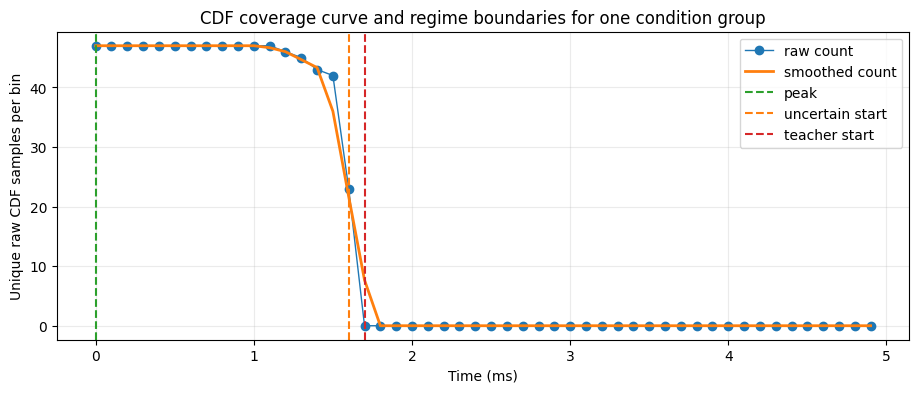

,time_bin,time_bin_start_ms,n_raw,n_raw_smooth,coverage_ratio,regime
15200,0,0.0,47,47.000000,1.000000,raw_reliable
15201,1,0.1,47,47.000000,1.000000,raw_reliable
15202,2,0.2,47,47.000000,1.000000,raw_reliable
15203,3,0.3,47,47.000000,1.000000,raw_reliable
15204,4,0.4,47,47.000000,1.000000,raw_reliable
15205,5,0.5,47,47.000000,1.000000,raw_reliable
15206,6,0.6,47,47.000000,1.000000,raw_reliable
15207,7,0.7,47,47.000000,1.000000,raw_reliable
15208,8,0.8,47,47.000000,1.000000,raw_reliable
15209,9,0.9,47,47.000000,1.000000,raw_reliable


In [43]:
group_support = (
    cdf_labeled_df.groupby(REGIME_GROUP_COLS, dropna=False)
    .size()
    .sort_values(ascending=False)
)
selected_group_key = group_support.index[0]
selected_group = cdf_regime_bins_df.copy()
for col, val in zip(REGIME_GROUP_COLS, selected_group_key):
    selected_group = selected_group.loc[selected_group[col] == val]

plt.figure(figsize=(11, 4))
plt.plot(selected_group["time_bin_start_ms"], selected_group["n_raw"], marker="o", linewidth=1.0, label="raw count")
plt.plot(selected_group["time_bin_start_ms"], selected_group["n_raw_smooth"], linewidth=2.0, label="smoothed count")
plt.axvline(float(selected_group["b_peak"].iloc[0]) * BIN_MS, color="tab:green", linestyle="--", label="peak")
plt.axvline(float(selected_group["b_uncertain_start"].iloc[0]) * BIN_MS, color="tab:orange", linestyle="--", label="uncertain start")
plt.axvline(float(selected_group["b_teacher_start"].iloc[0]) * BIN_MS, color="tab:red", linestyle="--", label="teacher start")
plt.xlabel("Time (ms)")
plt.ylabel("Unique raw CDF samples per bin")
plt.title("CDF coverage curve and regime boundaries for one condition group")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

selected_group[["time_bin", "time_bin_start_ms", "n_raw", "n_raw_smooth", "coverage_ratio", "regime"]].head(20)


## Coverage Sanity Check

This plot is a quick visual check for the binning rule.

For one operating-condition group, it shows the smoothed count of raw CDF samples available in each `0.1 ms` bin and overlays the three transition markers:

- peak support
- `raw_reliable -> raw_uncertain`
- `raw_uncertain -> teacher_only`

If these boundaries look unreasonable for a group, the thresholds in the regime-definition cell are the place to tune.


## Raw-Uncertain Scatter Versus Teacher Gaussian

The next section builds a reader-facing comparison for a few representative `2000 bar / 5 bar` cases drawn from `Nozzle 1~8` and `T6~T9`.

For each nozzle, the notebook picks one condition group with the largest number of `raw_uncertain` CDF points inside that filter. The figure then overlays four layers:

- black scatter: measured `raw_uncertain` CDF points
- blue line: teacher-model predicted mean
- blue band: teacher-model `?1?`
- orange cloud: random samples drawn from the teacher Gaussian at the same times as the `raw_uncertain` observations

This presentation is meant to be intuitive for mechanical-engineering readers: it shows where the raw data start thinning out, and what the teacher is implicitly asserting as a probabilistic replacement in that regime.


In [44]:
from toy_inference_from_run import build_toy_feature_matrix, split_mu_logvar


def umbrella_to_tilt_radian(umbrella_angle_deg: float) -> float:
    return float(np.deg2rad((180.0 - float(umbrella_angle_deg)) / 2.0))


def build_teacher_raw_dict(meta_row: pd.Series) -> dict[str, float]:
    return {
        "tilt_angle_radian": umbrella_to_tilt_radian(meta_row["umbrella_angle_deg"]),
        "plumes": float(meta_row["plumes"]),
        "diameter_mm": float(meta_row["diameter_mm"]),
        "injection_duration_us": float(meta_row["injection_duration_us"]),
        "injection_pressure_bar": float(meta_row["injection_pressure_bar"]),
        "chamber_pressure_bar": float(meta_row["chamber_pressure_bar"]),
        "control_backpressure_bar": float(meta_row["control_backpressure_bar"]),
    }


def predict_teacher_gaussian(meta_row: pd.Series, time_ms: np.ndarray) -> pd.DataFrame:
    feature_columns = list(train_config["feature_columns"])
    time_feature = str(train_config.get("time_feature", "time_norm_0_5ms"))
    raw = build_teacher_raw_dict(meta_row)
    features_np = build_toy_feature_matrix(
        raw=raw,
        time_ms=np.asarray(time_ms, dtype=np.float32),
        scaler_state=scaler_state,
        feature_columns=feature_columns,
        time_feature=time_feature,
    )
    features = torch.as_tensor(features_np, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        out = model(features)
        mu, log_var = split_mu_logvar(out)

    mu_np = mu.detach().cpu().numpy().reshape(-1)
    log_var_np = log_var.detach().cpu().numpy().reshape(-1)
    std_floor = float(train_config.get("std_clamp_min", 0.0))
    std_np = np.maximum(np.sqrt(np.exp(log_var_np)), std_floor)
    return pd.DataFrame({
        "time_ms": np.asarray(time_ms, dtype=float),
        "mu_mm": mu_np.astype(float),
        "std_mm": std_np.astype(float),
    })


In [45]:
plot_candidates_df = cdf_labeled_df.copy()
plot_candidates_df["folder_name"] = plot_candidates_df["file_path"].str.replace("\\", "/", regex=False).str.split("/").str[-2]
plot_candidates_df["nozzle_idx"] = pd.to_numeric(
    plot_candidates_df["experiment_name"].str.extract(r"Nozzle(\d+)")[0],
    errors="coerce",
)
candidate_mask = (
    plot_candidates_df["nozzle_idx"].between(1, 8)
    & plot_candidates_df["folder_name"].isin(["T6", "T7", "T8", "T9"])
    & np.isclose(plot_candidates_df["injection_pressure_bar"].astype(float), 2000.0)
    & np.isclose(plot_candidates_df["chamber_pressure_bar"].astype(float), 5.0)
)
plot_candidates_df = plot_candidates_df.loc[candidate_mask].copy()
plot_candidates_df["nozzle_name"] = "Nozzle " + plot_candidates_df["nozzle_idx"].astype(int).astype(str)

selected_condition_summary = (
    plot_candidates_df.groupby(
        ["experiment_name", "nozzle_idx", "nozzle_name", "folder_name"],
        dropna=False,
    )
    .agg(
        raw_uncertain_n=("regime", lambda s: int((s == "raw_uncertain").sum())),
        raw_reliable_n=("regime", lambda s: int((s == "raw_reliable").sum())),
        teacher_only_n=("regime", lambda s: int((s == "teacher_only").sum())),
        plumes=("plumes", "first"),
        diameter_mm=("diameter_mm", "first"),
        umbrella_angle_deg=("umbrella_angle_deg", "first"),
        injection_duration_us=("injection_duration_us", "first"),
        injection_pressure_bar=("injection_pressure_bar", "first"),
        chamber_pressure_bar=("chamber_pressure_bar", "first"),
        control_backpressure_bar=("control_backpressure_bar", "first"),
    )
    .reset_index()
)
selected_condition_summary = selected_condition_summary.loc[selected_condition_summary["raw_uncertain_n"] > 0].copy()
selected_condition_summary = (
    selected_condition_summary
    .sort_values(["nozzle_idx", "raw_uncertain_n", "folder_name"], ascending=[True, False, True])
    .drop_duplicates(subset=["nozzle_idx"], keep="first")
    .sort_values(["nozzle_idx"])
    .reset_index(drop=True)
)

selected_condition_summary



,experiment_name,nozzle_idx,nozzle_name,folder_name,raw_uncertain_n,raw_reliable_n,teacher_only_n,plumes,diameter_mm,umbrella_angle_deg,injection_duration_us,injection_pressure_bar,chamber_pressure_bar,control_backpressure_bar
0,BC20241003_HZ_Nozzle1,1.0,Nozzle 1,T6,80,725,7,10,0.384,140,715.0,2000,5,4
1,BC20241017_HZ_Nozzle2,2.0,Nozzle 2,T8,66,776,73,10,0.375,140,661.5,2000,5,4
2,BC20241014_HZ_Nozzle3,3.0,Nozzle 3,T6,108,591,37,10,0.365,140,709.0,2000,5,4
3,BC20241007_HZ_Nozzle4,4.0,Nozzle 4,T6,92,764,28,10,0.355,140,689.5,2000,5,4
4,BC20241010_HZ_Nozzle5,5.0,Nozzle 5,T7,106,824,5,11,0.348,140,735.0,2000,5,4
5,BC20241011_HZ_Nozzle6,6.0,Nozzle 6,T7,43,899,12,12,0.333,140,774.0,2000,5,4
6,BC20241015_HZ_Nozzle7,7.0,Nozzle 7,T7,73,955,6,12,0.365,164,736.2,2000,5,4
7,BC20241016_HZ_Nozzle8,8.0,Nozzle 8,T8,56,919,24,10,0.365,130,753.0,2000,5,4


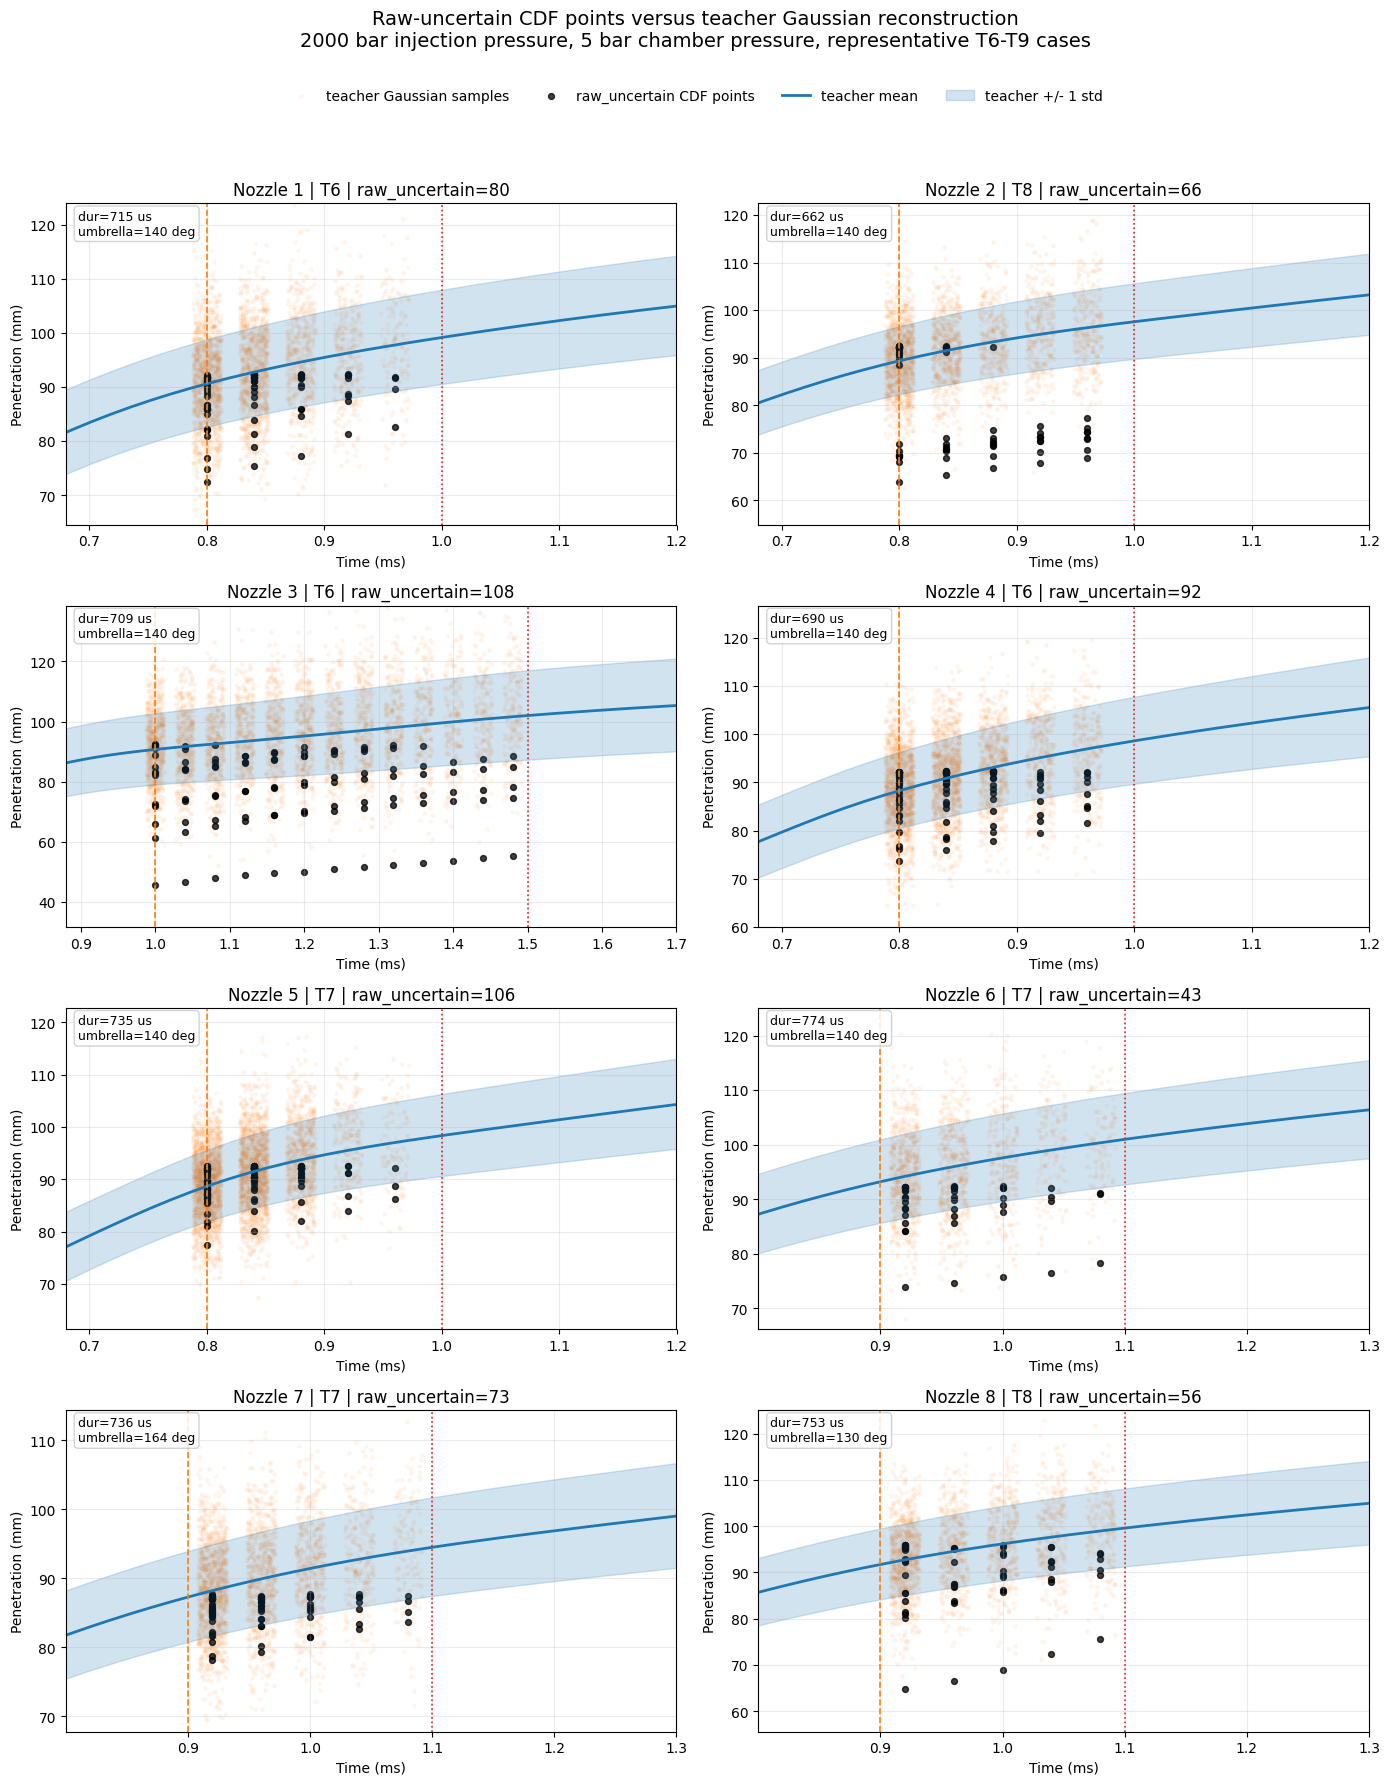

Saved figure to: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\figures\raw_uncertain_vs_teacher_gaussian_2000bar_5bar.png


In [46]:
RNG = np.random.default_rng(20260331)
TEACHER_SAMPLES_PER_POINT = 40
TEACHER_X_JITTER_MS = 0.012
TEACHER_CURVE_POINTS = 300
PLOT_SAVE_PATH = MLP_ROOT / "figures" / "raw_uncertain_vs_teacher_gaussian_2000bar_5bar.png"
PLOT_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

n_panels = len(selected_condition_summary)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.2 * nrows), sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, (_, cond_row) in zip(axes, selected_condition_summary.iterrows()):
    cond_mask = (
        (plot_candidates_df["experiment_name"] == cond_row["experiment_name"])
        & (plot_candidates_df["folder_name"] == cond_row["folder_name"])
    )
    cond_df = plot_candidates_df.loc[cond_mask].copy()
    raw_uncertain_df = (
        cond_df.loc[cond_df["regime"] == "raw_uncertain", ["time_ms", "penetration_mm"]]
        .dropna()
        .sort_values(["time_ms", "penetration_mm"])
        .reset_index(drop=True)
    )
    regime_row = cond_df[["b_uncertain_start", "b_teacher_start"]].drop_duplicates().iloc[0]

    if raw_uncertain_df.empty:
        ax.set_visible(False)
        continue

    curve_time_ms = np.linspace(0.0, 5.0, TEACHER_CURVE_POINTS, dtype=np.float32)
    teacher_curve_df = predict_teacher_gaussian(cond_row, curve_time_ms)
    teacher_at_raw_df = predict_teacher_gaussian(cond_row, raw_uncertain_df["time_ms"].to_numpy(dtype=np.float32))

    draw_mu = teacher_at_raw_df["mu_mm"].to_numpy(dtype=float)
    draw_std = teacher_at_raw_df["std_mm"].to_numpy(dtype=float)
    draw_time = teacher_at_raw_df["time_ms"].to_numpy(dtype=float)
    sampled_y = RNG.normal(
        loc=np.broadcast_to(draw_mu, (TEACHER_SAMPLES_PER_POINT, len(draw_mu))),
        scale=np.broadcast_to(draw_std, (TEACHER_SAMPLES_PER_POINT, len(draw_std))),
    )
    sampled_x = np.broadcast_to(draw_time, sampled_y.shape) + RNG.uniform(
        low=-TEACHER_X_JITTER_MS,
        high=TEACHER_X_JITTER_MS,
        size=sampled_y.shape,
    )

    ax.scatter(
        sampled_x.ravel(),
        sampled_y.ravel(),
        s=6,
        alpha=0.05,
        color="tab:orange",
        label="teacher Gaussian samples",
        rasterized=True,
    )
    ax.scatter(
        raw_uncertain_df["time_ms"],
        raw_uncertain_df["penetration_mm"],
        s=18,
        alpha=0.75,
        color="black",
        label="raw_uncertain CDF points",
    )
    ax.plot(
        teacher_curve_df["time_ms"],
        teacher_curve_df["mu_mm"],
        color="tab:blue",
        linewidth=2.0,
        label="teacher mean",
    )
    ax.fill_between(
        teacher_curve_df["time_ms"],
        teacher_curve_df["mu_mm"] - teacher_curve_df["std_mm"],
        teacher_curve_df["mu_mm"] + teacher_curve_df["std_mm"],
        color="tab:blue",
        alpha=0.2,
        label="teacher +/- 1 std",
    )

    uncertain_start_ms = float(regime_row["b_uncertain_start"]) * BIN_MS
    teacher_start_ms = float(regime_row["b_teacher_start"]) * BIN_MS
    ax.axvline(uncertain_start_ms, color="tab:orange", linestyle="--", linewidth=1.2)
    ax.axvline(teacher_start_ms, color="tab:red", linestyle=":", linewidth=1.2)

    local_x_min = max(0.0, min(raw_uncertain_df["time_ms"].min() - 0.12, uncertain_start_ms - 0.10))
    local_x_max = min(5.0, max(raw_uncertain_df["time_ms"].max() + 0.15, teacher_start_ms + 0.20))
    local_curve_df = teacher_curve_df.loc[
        (teacher_curve_df["time_ms"] >= local_x_min) & (teacher_curve_df["time_ms"] <= local_x_max)
    ].copy()
    if local_curve_df.empty:
        local_curve_df = teacher_curve_df.copy()

    local_y_candidates = np.concatenate([
        raw_uncertain_df["penetration_mm"].to_numpy(dtype=float),
        local_curve_df["mu_mm"].to_numpy(dtype=float),
        (local_curve_df["mu_mm"] - 1.25 * local_curve_df["std_mm"]).to_numpy(dtype=float),
        (local_curve_df["mu_mm"] + 1.25 * local_curve_df["std_mm"]).to_numpy(dtype=float),
    ])
    local_y_candidates = local_y_candidates[np.isfinite(local_y_candidates)]
    y_span = float(max(local_y_candidates.max() - local_y_candidates.min(), 8.0))
    y_margin = float(max(4.0, 0.18 * y_span))
    y_min = max(0.0, float(local_y_candidates.min()) - y_margin)
    y_max = float(local_y_candidates.max()) + y_margin

    ax.set_xlim(local_x_min, local_x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Penetration (mm)")
    ax.set_title(
        f"{cond_row['nozzle_name']} | {cond_row['folder_name']} | raw_uncertain={int(cond_row['raw_uncertain_n'])}"
    )
    ax.text(
        0.02,
        0.98,
        f"dur={float(cond_row['injection_duration_us']):.0f} us\numbrella={float(cond_row['umbrella_angle_deg']):.0f} deg",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
    )

for ax in axes[n_panels:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    "Raw-uncertain CDF points versus teacher Gaussian reconstruction\n2000 bar injection pressure, 5 bar chamber pressure, representative T6-T9 cases",
    y=1.06,
    fontsize=14,
)
fig.tight_layout()
fig.savefig(PLOT_SAVE_PATH, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {PLOT_SAVE_PATH}")


### How To Read The Figure

A practical reading of these panels is:

- if the black `raw_uncertain` cloud still sits well inside the orange teacher-sample cloud and the blue `?1?` band, then using teacher supervision there is a mild extrapolation of the raw data trend rather than a violent replacement
- if the black points already sit systematically below the blue mean while the time axis is moving toward the `teacher_only` boundary, that is a visual signature consistent with late-time raw attenuation or right-side thinning
- if the teacher band is too narrow compared with the black scatter, the teacher is overconfident for that operating condition and should be down-weighted when used for distillation

The orange and red vertical lines mark the coverage-based regime boundaries inferred earlier from the raw CDF support counts.


In [47]:
first_batch = next(iter(loader))
print("batch series:", first_batch["series"].shape)
print("batch mask:", first_batch["mask"].shape)
print("batch time_ms:", first_batch["time_ms"].shape)
print("first sample meta:")
print(first_batch["meta"])


batch series: torch.Size([16, 67, 3])
batch mask: torch.Size([16, 67, 3])
batch time_ms: torch.Size([16, 67])
first sample meta:
{'experiment_name': ['BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view', 'BC20220627 - Heinzman DS300 - Mie Top view'], 'file_path': ['C:\\Users\\Jiang\\Documents\\Mie_Postprocessing_Py\\BC20220627 - Heinzman DS300 - Mie Top view\\T1

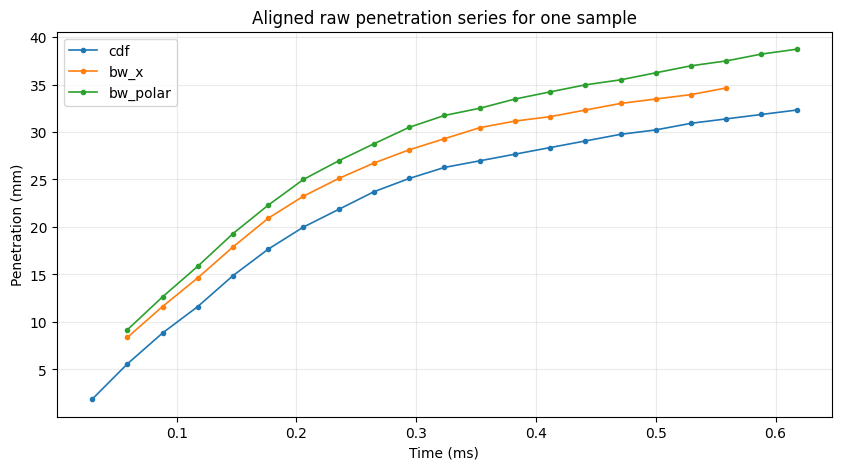

In [48]:
sample_idx = 0
sample_time = time_ms_tensor[sample_idx]
sample_series = series_tensor[sample_idx]
sample_mask = mask_stack[sample_idx]

plt.figure(figsize=(10, 5))
for channel_idx, source in enumerate(SOURCES):
    valid = sample_mask[:, channel_idx]
    plt.plot(sample_time[valid], sample_series[valid, channel_idx], marker="o", markersize=3, linewidth=1.2, label=source)

plt.xlabel("Time (ms)")
plt.ylabel("Penetration (mm)")
plt.title("Aligned raw penetration series for one sample")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Inspection Outputs

The last cells are simple notebook sanity checks:

- inspect one batch coming out of the `DataLoader`
- visualize one aligned multi-source trajectory sample

These checks are useful before wiring the tables into a new loss or a new training notebook, because they confirm that the shapes, masks, and time alignment are internally consistent.


## Hydraulic Delay Report

Before using onset as a soft auxiliary target, the notebook first reports the existing engineered delay statistics.

This is intentionally descriptive only:

- `delay_frames_used` and `delay_ms` are summarized for the CDF dataset
- the report is grouped by experiment and by `delay_source`
- no delay head is added to the student model


Delay overall summary (ms):
  count     mean      std  min  10%  25%  50%      75%      90%      max
21675.0 0.512872 0.038351 0.24 0.48 0.48 0.52 0.529412 0.558824 0.764706

Delay by source:
                      n_samples  delay_ms_mean  delay_ms_std  delay_ms_median  delay_frames_median
delay_source                                                                                      
area                      21592       0.512811      0.038336             0.52                 17.0
penetration_fallback         83       0.528987      0.038973             0.52                 14.0


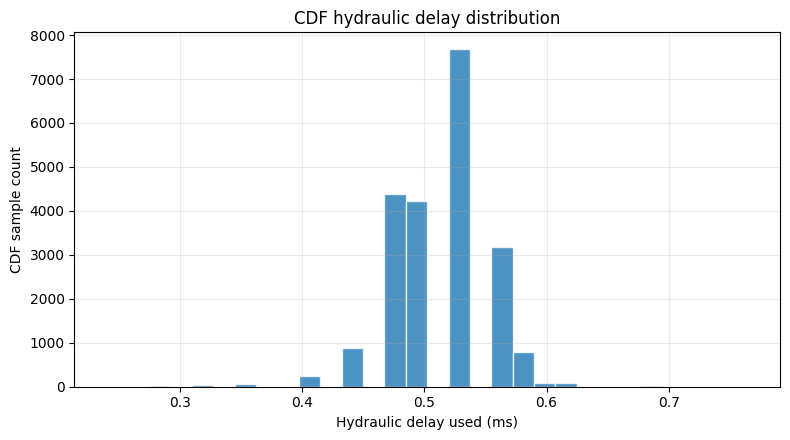

,n_samples,delay_ms_mean,delay_ms_std,delay_ms_median,delay_ms_p10,delay_ms_p90,delay_frames_median
experiment_name,,,,,,,
BC20241014_HZ_Nozzle3,723,0.454993,0.048224,0.440000,0.40,0.520000,11.0
BC20241003_HZ_Nozzle1,1138,0.464534,0.037921,0.480000,0.44,0.520000,12.0
BC20241016_HZ_Nozzle8,931,0.493620,0.037493,0.480000,0.48,0.520000,12.0
BC20241017_HZ_Nozzle2,2449,0.500302,0.036587,0.480000,0.48,0.560000,12.0
BC20241011_HZ_Nozzle6,835,0.525892,0.034790,0.520000,0.48,0.560000,13.0
BC20241010_HZ_Nozzle5,1285,0.510475,0.026817,0.520000,0.48,0.560000,13.0
BC20241015_HZ_Nozzle7,917,0.517993,0.029484,0.520000,0.48,0.560000,13.0
BC20241007_HZ_Nozzle4,1195,0.505071,0.024380,0.520000,0.48,0.520000,13.0
BC20220627 - Heinzman DS300 - Mie Top view,12202,0.524543,0.032415,0.529412,0.50,0.558824,18.0


In [49]:
delay_report_df = cdf_wide_df.loc[:, [
    "experiment_name",
    "file_path",
    "file_name",
    "plume_idx",
    "fps",
    "delay_frames_raw",
    "delay_frames_used",
    "delay_source",
]].copy()

delay_report_df["delay_frames_raw"] = pd.to_numeric(delay_report_df["delay_frames_raw"], errors="coerce")
delay_report_df["delay_frames_used"] = pd.to_numeric(delay_report_df["delay_frames_used"], errors="coerce")
delay_report_df["fps"] = pd.to_numeric(delay_report_df["fps"], errors="coerce")
delay_report_df["delay_ms"] = delay_report_df["delay_frames_used"] / delay_report_df["fps"] * 1e3

delay_overall_summary = delay_report_df["delay_ms"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame().T

delay_by_experiment = (
    delay_report_df.groupby("experiment_name", dropna=False)
    .agg(
        n_samples=("delay_ms", "size"),
        delay_ms_mean=("delay_ms", "mean"),
        delay_ms_std=("delay_ms", "std"),
        delay_ms_median=("delay_ms", "median"),
        delay_ms_p10=("delay_ms", lambda s: float(np.nanpercentile(s, 10))),
        delay_ms_p90=("delay_ms", lambda s: float(np.nanpercentile(s, 90))),
        delay_frames_median=("delay_frames_used", "median"),
    )
    .sort_values("delay_ms_median")
)

delay_by_source = (
    delay_report_df.groupby("delay_source", dropna=False)
    .agg(
        n_samples=("delay_ms", "size"),
        delay_ms_mean=("delay_ms", "mean"),
        delay_ms_std=("delay_ms", "std"),
        delay_ms_median=("delay_ms", "median"),
        delay_frames_median=("delay_frames_used", "median"),
    )
    .sort_values("delay_ms_median")
)

print("Delay overall summary (ms):")
print(delay_overall_summary.to_string(index=False))
print()
print("Delay by source:")
print(delay_by_source.to_string())

plt.figure(figsize=(8, 4.5))
plt.hist(delay_report_df["delay_ms"].dropna().to_numpy(), bins=30, color="tab:blue", alpha=0.8, edgecolor="white")
plt.xlabel("Hydraulic delay used (ms)")
plt.ylabel("CDF sample count")
plt.title("CDF hydraulic delay distribution")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

delay_by_experiment.head(12)


## CDF Refinement Dataset And Student Model

This section builds the training-ready refinement dataset from the CDF wide table.

Key design choices:

- a fixed `0~5 ms` grid is used for student and teacher evaluation
- raw CDF observations are mapped onto that grid where available
- regime-dependent raw/KD weights are attached per time step
- onset is supervised as an auxiliary head only
- the student remains a pointwise MLP, but batching is sequence-wise so `d1` and `d2` still operate on contiguous trajectories


In [57]:
from datetime import datetime
import json
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from toy_inference_from_run import PenetrationMLP

TEACHER_MODEL = model.eval()

REFINE_CONFIG = {
    "seed": int(train_config.get("seed", 42)),
    "time_min_ms": float(scaler_state["time"]["min_ms"]),
    "time_max_ms": float(scaler_state["time"]["max_ms"]),
    "n_points": int(train_config.get("n_points", 1024)),
    "batch_size": 64,
    "epochs": 150,
    "learning_rate": 3e-3,
    "weight_decay": float(train_config.get("weight_decay", 6e-4)),
    "val_frac": float(train_config.get("splits", {}).get("val", 0.15)),
    "test_frac": float(train_config.get("splits", {}).get("test", 0.15)),
    "num_workers": 0,
    "pin_memory": False,
    "log_var_bounds": (-10.0, 6.0),
    "nll_eps": 1e-12,
    "lambda_onset": 0.1,
    "lambda_anchor": 1e-2,
    "d1_positive_weight": 5e-5,
    "d2_concave_weight": 5e-4,
    "d2_start_ms": 0.5,
    "d2_transition_ms": 0.05,
    "onset_ramp_ms": 0.12,
    "onset_loss_window_ms": 0.2,
    "anchor_window_ms": 0.15,
    "sigma_conf_ref_mm": 10.0,
    "raw_weights": {"raw_reliable": 1.0, "raw_uncertain": 0.0, "teacher_only": 0.0},
    "kd_weights": {"raw_reliable": 0.25, "raw_uncertain": 1.0, "teacher_only": 0.75},
    "runs_root": str(MLP_ROOT / "runs_mlp"),
}

FEATURE_COLUMNS = list(train_config["feature_columns"])
TIME_FEATURE = str(train_config.get("time_feature", "time_norm_0_5ms"))

raw_time_bin_counts = cdf_labeled_df.groupby("time_bin", dropna=False).size().reindex(range(N_BINS), fill_value=0).astype(float)
raw_time_bin_reference = float(raw_time_bin_counts[raw_time_bin_counts > 0].mean()) if np.any(raw_time_bin_counts > 0) else 1.0
GLOBAL_TIME_BIN_WEIGHTS = (raw_time_bin_reference / raw_time_bin_counts.replace(0.0, np.nan)).fillna(1.0).clip(0.5, 2.0).to_numpy(dtype=np.float32)


def set_global_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(REFINE_CONFIG["seed"])


In [58]:
def split_indices(n_items: int, *, seed: int, val_frac: float, test_frac: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    indices = np.arange(n_items, dtype=int)
    rng.shuffle(indices)

    n_test = int(round(n_items * test_frac))
    n_val = int(round(n_items * val_frac))
    n_test = min(max(n_test, 1), max(n_items - 2, 1))
    n_val = min(max(n_val, 1), max(n_items - n_test - 1, 1))

    test_idx = indices[:n_test]
    val_idx = indices[n_test:n_test + n_val]
    train_idx = indices[n_test + n_val:]
    return train_idx, val_idx, test_idx


class CDFRefinementSequenceDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        regime_bins_df: pd.DataFrame,
        *,
        scaler_state: dict,
        feature_columns: list[str],
        time_feature: str,
        config: dict,
    ) -> None:
        self.df = df.reset_index(drop=True).copy()
        self.scaler_state = scaler_state
        self.feature_columns = list(feature_columns)
        self.time_feature = str(time_feature)
        self.config = dict(config)

        self.time_min_ms = float(config["time_min_ms"])
        self.time_max_ms = float(config["time_max_ms"])
        self.n_points = int(config["n_points"])
        self.time_grid_ms = np.linspace(self.time_min_ms, self.time_max_ms, self.n_points, dtype=np.float32)
        self.time_bins = np.floor(self.time_grid_ms / BIN_MS).astype(int).clip(0, N_BINS - 1)

        self.time_cols = prefixed_columns(self.df, "time_ms_")
        self.pen_cols = prefixed_columns(self.df, "penetration_mm_")
        if len(self.time_cols) != len(self.pen_cols):
            raise ValueError("CDF wide table time/penetration columns do not match.")

        self._raw_weight_lut, self._kd_weight_lut = self._build_regime_weight_lookup(regime_bins_df)
        self.onset_bins = self._build_onset_bins()

    def _build_regime_weight_lookup(self, regime_bins_df: pd.DataFrame) -> tuple[dict, dict]:
        raw_lut: dict[tuple, np.ndarray] = {}
        kd_lut: dict[tuple, np.ndarray] = {}
        for group_key, g in regime_bins_df.groupby(REGIME_GROUP_COLS, dropna=False):
            arr = np.full(N_BINS, "teacher_only", dtype=object)
            g_sorted = g.sort_values("time_bin")
            arr[g_sorted["time_bin"].to_numpy(dtype=int)] = g_sorted["regime"].to_numpy(dtype=object)
            raw_lut[group_key] = np.asarray([self.config["raw_weights"][reg] for reg in arr], dtype=np.float32)
            kd_lut[group_key] = np.asarray([self.config["kd_weights"][reg] for reg in arr], dtype=np.float32)
        return raw_lut, kd_lut

    def _row_group_key(self, row: pd.Series) -> tuple:
        return tuple(row[col] for col in REGIME_GROUP_COLS)

    def _build_onset_bins(self) -> np.ndarray:
        onset_bins = np.zeros(len(self.df), dtype=np.int64)
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            time_vals = row[self.time_cols].to_numpy(dtype=float)
            pen_vals = row[self.pen_cols].to_numpy(dtype=float)
            valid = np.isfinite(time_vals) & np.isfinite(pen_vals)
            if np.any(valid):
                first_t = float(np.nanmin(time_vals[valid]))
                onset_bins[idx] = int(np.floor(first_t / BIN_MS))
        return onset_bins.clip(0, N_BINS - 1)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        teacher_raw = build_teacher_raw_dict(row)
        features_np = build_toy_feature_matrix(
            raw=teacher_raw,
            time_ms=self.time_grid_ms,
            scaler_state=self.scaler_state,
            feature_columns=self.feature_columns,
            time_feature=self.time_feature,
        ).astype(np.float32)

        raw_target = np.full(self.n_points, np.nan, dtype=np.float32)
        raw_valid = np.zeros(self.n_points, dtype=bool)

        observed_time = row[self.time_cols].to_numpy(dtype=float)
        observed_pen = row[self.pen_cols].to_numpy(dtype=float)
        finite = np.isfinite(observed_time) & np.isfinite(observed_pen)
        if np.any(finite):
            obs_time = observed_time[finite]
            obs_pen = observed_pen[finite]
            obs_idx = np.clip(
                np.round((obs_time - self.time_min_ms) / max(self.time_max_ms - self.time_min_ms, 1e-12) * (self.n_points - 1)).astype(int),
                0,
                self.n_points - 1,
            )
            for grid_idx in np.unique(obs_idx):
                vals = obs_pen[obs_idx == grid_idx]
                raw_target[grid_idx] = np.float32(np.mean(vals))
                raw_valid[grid_idx] = True

        group_key = self._row_group_key(row)
        raw_regime_weights = self._raw_weight_lut[group_key][self.time_bins].copy()
        kd_regime_weights = self._kd_weight_lut[group_key][self.time_bins].copy()
        time_bin_weights = GLOBAL_TIME_BIN_WEIGHTS[self.time_bins].astype(np.float32)
        raw_weights = raw_regime_weights * raw_valid.astype(np.float32) * time_bin_weights
        kd_regime_weights = kd_regime_weights * time_bin_weights

        onset_target = np.clip(self.time_grid_ms / max(float(self.config["onset_ramp_ms"]), 1e-6), 0.0, 1.0).astype(np.float32)
        onset_loss_mask = ((self.time_grid_ms >= 0.0) & (self.time_grid_ms <= float(self.config["onset_loss_window_ms"]))).astype(np.float32)
        anchor_weight = np.clip(1.0 - self.time_grid_ms / max(float(self.config["anchor_window_ms"]), 1e-6), 0.0, 1.0).astype(np.float32)

        return {
            "features": torch.from_numpy(features_np),
            "time_ms": torch.from_numpy(self.time_grid_ms.copy()),
            "raw_target": torch.from_numpy(np.nan_to_num(raw_target, nan=0.0).astype(np.float32)),
            "raw_valid": torch.from_numpy(raw_valid),
            "raw_weight": torch.from_numpy(raw_weights.astype(np.float32)),
            "kd_weight": torch.from_numpy(kd_regime_weights.astype(np.float32)),
            "onset_target": torch.from_numpy(onset_target),
            "onset_loss_mask": torch.from_numpy(onset_loss_mask),
            "anchor_weight": torch.from_numpy(anchor_weight),
            "sample_idx": torch.tensor(int(idx), dtype=torch.long),
        }


def build_sequence_sampler_weights(dataset: CDFRefinementSequenceDataset) -> np.ndarray:
    counts = pd.Series(dataset.onset_bins).value_counts().to_dict()
    weights = np.asarray([1.0 / counts[int(bin_id)] for bin_id in dataset.onset_bins], dtype=np.float64)
    return weights / weights.mean()


In [59]:
train_idx, val_idx, test_idx = split_indices(
    len(cdf_wide_df),
    seed=REFINE_CONFIG["seed"],
    val_frac=REFINE_CONFIG["val_frac"],
    test_frac=REFINE_CONFIG["test_frac"],
)

df_refine_train = cdf_wide_df.iloc[train_idx].reset_index(drop=True)
df_refine_val = cdf_wide_df.iloc[val_idx].reset_index(drop=True)
df_refine_test = cdf_wide_df.iloc[test_idx].reset_index(drop=True)

dataset_refine_train = CDFRefinementSequenceDataset(
    df_refine_train,
    cdf_regime_bins_df,
    scaler_state=scaler_state,
    feature_columns=FEATURE_COLUMNS,
    time_feature=TIME_FEATURE,
    config=REFINE_CONFIG,
)
dataset_refine_val = CDFRefinementSequenceDataset(
    df_refine_val,
    cdf_regime_bins_df,
    scaler_state=scaler_state,
    feature_columns=FEATURE_COLUMNS,
    time_feature=TIME_FEATURE,
    config=REFINE_CONFIG,
)
dataset_refine_test = CDFRefinementSequenceDataset(
    df_refine_test,
    cdf_regime_bins_df,
    scaler_state=scaler_state,
    feature_columns=FEATURE_COLUMNS,
    time_feature=TIME_FEATURE,
    config=REFINE_CONFIG,
)

train_sampler_weights = build_sequence_sampler_weights(dataset_refine_train)
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_sampler_weights, dtype=torch.double),
    num_samples=len(dataset_refine_train),
    replacement=True,
)

train_loader_refine = DataLoader(
    dataset_refine_train,
    batch_size=REFINE_CONFIG["batch_size"],
    sampler=train_sampler,
    num_workers=REFINE_CONFIG["num_workers"],
    pin_memory=REFINE_CONFIG["pin_memory"],
)
val_loader_refine = DataLoader(
    dataset_refine_val,
    batch_size=REFINE_CONFIG["batch_size"],
    shuffle=False,
    num_workers=REFINE_CONFIG["num_workers"],
    pin_memory=REFINE_CONFIG["pin_memory"],
)
test_loader_refine = DataLoader(
    dataset_refine_test,
    batch_size=REFINE_CONFIG["batch_size"],
    shuffle=False,
    num_workers=REFINE_CONFIG["num_workers"],
    pin_memory=REFINE_CONFIG["pin_memory"],
)

print("refinement split sizes:", {
    "train": len(dataset_refine_train),
    "val": len(dataset_refine_val),
    "test": len(dataset_refine_test),
})
print("sequence sampler onset-bin range:", int(dataset_refine_train.onset_bins.min()), int(dataset_refine_train.onset_bins.max()))


refinement split sizes: {'train': 15173, 'val': 3251, 'test': 3251}
sequence sampler onset-bin range: 0 2


## Distillation Refinement Loss

The student keeps the same pointwise MLP family as the teacher, but its output dimension becomes 3:

- `mu`
- `logvar`
- `onset_logit`

Teacher supervision is computed online from the frozen archived model on the same feature tensor used by the student.


In [60]:
def build_student_model_from_teacher(teacher_model: torch.nn.Module, teacher_config: dict, device: torch.device) -> torch.nn.Module:
    student = PenetrationMLP(
        input_dim=int(teacher_config["input_dim"]),
        hidden_dims=[int(x) for x in teacher_config["hidden_dims"]],
        output_dim=3,
        activation=str(teacher_config.get("activation", "relu")),
        dropout=float(teacher_config.get("dropout", 0.0)),
    ).to(device)

    teacher_state = teacher_model.state_dict()
    student_state = student.state_dict()
    for key, value in teacher_state.items():
        if key in student_state and student_state[key].shape == value.shape:
            student_state[key] = value.clone()

    final_weight_key = [k for k in student_state if k.endswith("weight")][-1]
    final_bias_key = [k for k in student_state if k.endswith("bias")][-1]
    student_state[final_weight_key][:2] = teacher_state[final_weight_key]
    student_state[final_bias_key][:2] = teacher_state[final_bias_key]
    student_state[final_weight_key][2].zero_()
    student_state[final_bias_key][2].zero_()
    student.load_state_dict(student_state)
    return student


def split_student_output(model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    mu, log_var, onset_logit = torch.split(model_output, [1, 1, 1], dim=-1)
    return mu, log_var, onset_logit


def weighted_mean(values: torch.Tensor, weights: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    denom = weights.sum()
    if float(denom.detach().cpu()) <= eps:
        return values.new_tensor(0.0)
    return (values * weights).sum() / denom


def derivative_shape_penalty(
    mu: torch.Tensor,
    time_ms: torch.Tensor,
    *,
    d2_start_ms: float,
    d2_transition_ms: float,
) -> tuple[torch.Tensor, torch.Tensor]:
    d1 = mu[:, 1:] - mu[:, :-1]
    d1_penalty = torch.relu(-d1).pow(2).mean()

    if mu.shape[1] <= 2:
        return d1_penalty, mu.new_tensor(0.0)

    d2 = mu[:, 2:] - 2.0 * mu[:, 1:-1] + mu[:, :-2]
    t_center_ms = time_ms[:, 1:-1]
    gate = torch.sigmoid((t_center_ms - float(d2_start_ms)) / max(float(d2_transition_ms), 1e-6))
    d2_penalty = (torch.relu(d2).pow(2) * gate).mean()
    return d1_penalty, d2_penalty


def compute_teacher_outputs(teacher_model: torch.nn.Module, features: torch.Tensor, *, log_var_bounds: tuple[float, float], nll_eps: float) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    bsz, n_points, feat_dim = features.shape
    with torch.no_grad():
        teacher_flat = teacher_model(features.reshape(bsz * n_points, feat_dim))
        teacher_mu_flat, teacher_log_var_flat = split_mu_logvar(teacher_flat)
    teacher_mu = teacher_mu_flat.reshape(bsz, n_points, 1)
    teacher_log_var = teacher_log_var_flat.reshape(bsz, n_points, 1)
    teacher_log_var = torch.clamp(teacher_log_var, min=log_var_bounds[0], max=log_var_bounds[1])
    teacher_std = torch.clamp_min(torch.exp(0.5 * teacher_log_var), float(train_config.get("std_clamp_min", 0.0)))
    teacher_var = teacher_std.pow(2) + nll_eps
    return teacher_mu, teacher_log_var, teacher_var


def refinement_loss(
    student_output: torch.Tensor,
    teacher_mu: torch.Tensor,
    teacher_var: torch.Tensor,
    batch: dict,
    *,
    config: dict,
) -> tuple[torch.Tensor, dict]:
    mu, log_var, onset_logit = split_student_output(student_output)
    log_var = torch.clamp(log_var, min=config["log_var_bounds"][0], max=config["log_var_bounds"][1])
    var = torch.exp(log_var) + float(config["nll_eps"])

    raw_target = batch["raw_target"].unsqueeze(-1)
    raw_weight = batch["raw_weight"]
    kd_weight = batch["kd_weight"]
    onset_target = batch["onset_target"]
    onset_loss_mask = batch["onset_loss_mask"]
    anchor_weight = batch["anchor_weight"]
    time_ms = batch["time_ms"]

    raw_nll_point = 0.5 * (log_var + (mu - raw_target).pow(2) / var)
    raw_loss = weighted_mean(raw_nll_point.squeeze(-1), raw_weight)

    kl_point = 0.5 * (torch.log(var / teacher_var) + (teacher_var + (teacher_mu - mu).pow(2)) / var - 1.0)
    teacher_std = torch.sqrt(teacher_var)
    conf_weight = torch.clamp(float(config["sigma_conf_ref_mm"]) / teacher_std, min=0.25, max=1.0).squeeze(-1)
    kd_loss = weighted_mean(kl_point.squeeze(-1), kd_weight * conf_weight)

    onset_bce = F.binary_cross_entropy_with_logits(onset_logit.squeeze(-1), onset_target, reduction="none")
    onset_loss = weighted_mean(onset_bce, onset_loss_mask)

    anchor_loss = weighted_mean(mu.squeeze(-1).pow(2), anchor_weight)

    d1_penalty, d2_penalty = derivative_shape_penalty(
        mu.squeeze(-1),
        time_ms,
        d2_start_ms=config["d2_start_ms"],
        d2_transition_ms=config["d2_transition_ms"],
    )

    loss = (
        raw_loss
        + kd_loss
        + float(config["lambda_onset"]) * onset_loss
        + float(config["lambda_anchor"]) * anchor_loss
        + float(config["d1_positive_weight"]) * d1_penalty
        + float(config["d2_concave_weight"]) * d2_penalty
    )

    metrics = {
        "loss": float(loss.detach().cpu()),
        "raw_nll": float(raw_loss.detach().cpu()),
        "kd_kl": float(kd_loss.detach().cpu()),
        "onset_bce": float(onset_loss.detach().cpu()),
        "anchor": float(anchor_loss.detach().cpu()),
        "d1_penalty": float(d1_penalty.detach().cpu()),
        "d2_penalty": float(d2_penalty.detach().cpu()),
        "teacher_conf_min": float(conf_weight.min().detach().cpu()),
        "teacher_conf_max": float(conf_weight.max().detach().cpu()),
    }
    return loss, metrics


In [61]:
student_model = build_student_model_from_teacher(TEACHER_MODEL, train_config, DEVICE)
student_model.eval()

refine_first_batch = next(iter(train_loader_refine))
refine_features = refine_first_batch["features"].to(DEVICE)

with torch.no_grad():
    refine_student_out = student_model(refine_features.reshape(-1, refine_features.shape[-1])).reshape(refine_features.shape[0], refine_features.shape[1], 3)
    refine_teacher_mu, refine_teacher_log_var, refine_teacher_var = compute_teacher_outputs(
        TEACHER_MODEL,
        refine_features,
        log_var_bounds=REFINE_CONFIG["log_var_bounds"],
        nll_eps=REFINE_CONFIG["nll_eps"],
    )

refine_loss, refine_metrics = refinement_loss(
    refine_student_out,
    refine_teacher_mu,
    refine_teacher_var,
    {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in refine_first_batch.items()},
    config=REFINE_CONFIG,
)

assert refine_student_out.shape[-1] == 3, "Student output must be [B, T, 3]."
assert np.isfinite(refine_metrics["loss"]), "Refinement loss must be finite."
assert 0.25 <= refine_metrics["teacher_conf_min"] <= 1.0, "Teacher confidence lower bound out of range."
assert 0.25 <= refine_metrics["teacher_conf_max"] <= 1.0, "Teacher confidence upper bound out of range."

print("Static refinement checks passed.")
print("student output shape:", tuple(refine_student_out.shape))
print("sample batch onset target min/max:", float(refine_first_batch["onset_target"].min()), float(refine_first_batch["onset_target"].max()))
print("raw supervised points in batch:", int(refine_first_batch["raw_weight"].gt(0).sum().item()))
print("refinement metrics:", refine_metrics)


Static refinement checks passed.
student output shape: (64, 1024, 3)
sample batch onset target min/max: 0.0 1.0
raw supervised points in batch: 1817
refinement metrics: {'loss': 4.9887800216674805, 'raw_nll': 4.072781085968018, 'kd_kl': -1.2793420767209795e-09, 'onset_bce': 0.6931474804878235, 'anchor': 84.6683578491211, 'd1_penalty': 4.7752408136148006e-05, 'd2_penalty': 0.0005602293531410396, 'teacher_conf_min': 0.49787068367004395, 'teacher_conf_max': 1.0}


## Tiny Overfit Check

The next cell does not run the full refinement job. It only checks that the new objective is behaviorally sane on a very small subset.


In [62]:
tiny_indices = np.arange(min(8, len(df_refine_train)), dtype=int)
df_refine_tiny = df_refine_train.iloc[tiny_indices].reset_index(drop=True)
dataset_refine_tiny = CDFRefinementSequenceDataset(
    df_refine_tiny,
    cdf_regime_bins_df,
    scaler_state=scaler_state,
    feature_columns=FEATURE_COLUMNS,
    time_feature=TIME_FEATURE,
    config=REFINE_CONFIG,
)
loader_refine_tiny = DataLoader(dataset_refine_tiny, batch_size=len(dataset_refine_tiny), shuffle=False)

tiny_model = build_student_model_from_teacher(TEACHER_MODEL, train_config, DEVICE)
tiny_optimizer = torch.optim.AdamW(
    tiny_model.parameters(),
    lr=REFINE_CONFIG["learning_rate"],
    weight_decay=REFINE_CONFIG["weight_decay"],
)

tiny_batch = next(iter(loader_refine_tiny))
tiny_batch_device = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in tiny_batch.items()}

def inspect_early_behavior(model_obj: torch.nn.Module, batch_device: dict) -> tuple[float, float]:
    model_obj.eval()
    with torch.no_grad():
        features = batch_device["features"]
        out = model_obj(features.reshape(-1, features.shape[-1])).reshape(features.shape[0], features.shape[1], 3)
        mu, _, onset_logit = split_student_output(out)
        early_idx = int(np.argmin(np.abs(batch_device["time_ms"][0].detach().cpu().numpy())))
        mu_zero = float(mu[:, early_idx, 0].mean().detach().cpu())
        onset_zero = float(torch.sigmoid(onset_logit[:, early_idx, 0]).mean().detach().cpu())
    return mu_zero, onset_zero

mu_zero_before, onset_zero_before = inspect_early_behavior(tiny_model, tiny_batch_device)

overfit_history = []
for step in range(30):
    tiny_model.train()
    tiny_optimizer.zero_grad(set_to_none=True)
    features = tiny_batch_device["features"]
    student_out = tiny_model(features.reshape(-1, features.shape[-1])).reshape(features.shape[0], features.shape[1], 3)
    teacher_mu, teacher_log_var, teacher_var = compute_teacher_outputs(
        TEACHER_MODEL,
        features,
        log_var_bounds=REFINE_CONFIG["log_var_bounds"],
        nll_eps=REFINE_CONFIG["nll_eps"],
    )
    loss, metrics = refinement_loss(student_out, teacher_mu, teacher_var, tiny_batch_device, config=REFINE_CONFIG)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(tiny_model.parameters(), 1.0)
    tiny_optimizer.step()
    overfit_history.append(metrics)

mu_zero_after, onset_zero_after = inspect_early_behavior(tiny_model, tiny_batch_device)

print("tiny overfit final metrics:", overfit_history[-1])
print("mu(near 0 ms):", {"before": mu_zero_before, "after": mu_zero_after})
print("sigmoid(onset_logit near 0 ms):", {"before": onset_zero_before, "after": onset_zero_after})


tiny overfit final metrics: {'loss': 6.2654032707214355, 'raw_nll': 2.8935296535491943, 'kd_kl': 0.3297419846057892, 'onset_bce': 0.6272827982902527, 'anchor': 292.09503173828125, 'd1_penalty': 57.627681732177734, 'd2_penalty': 111.14353942871094, 'teacher_conf_min': 0.49787068367004395, 'teacher_conf_max': 1.0}
mu(near 0 ms): {'before': 8.98573112487793, 'after': 2.547779083251953}
sigmoid(onset_logit near 0 ms): {'before': 0.5, 'after': 0.6776138544082642}


## Optional Full Refinement Training

The final cells define a full refinement loop and artifact-saving path, but they do not run by default.


In [63]:
def run_refinement_epoch(
    student_model: torch.nn.Module,
    teacher_model: torch.nn.Module,
    dataloader: DataLoader,
    *,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
    config: dict,
) -> dict:
    is_train = optimizer is not None
    student_model.train(mode=is_train)

    totals = {
        "loss": 0.0,
        "raw_nll": 0.0,
        "kd_kl": 0.0,
        "onset_bce": 0.0,
        "anchor": 0.0,
        "d1_penalty": 0.0,
        "d2_penalty": 0.0,
    }
    total_sequences = 0

    for batch in dataloader:
        batch_device = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        features = batch_device["features"]
        batch_size, n_points, feat_dim = features.shape

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        student_out = student_model(features.reshape(batch_size * n_points, feat_dim)).reshape(batch_size, n_points, 3)
        teacher_mu, teacher_log_var, teacher_var = compute_teacher_outputs(
            teacher_model,
            features,
            log_var_bounds=config["log_var_bounds"],
            nll_eps=config["nll_eps"],
        )
        loss, metrics = refinement_loss(student_out, teacher_mu, teacher_var, batch_device, config=config)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), 1.0)
            optimizer.step()

        total_sequences += batch_size
        for key in totals:
            totals[key] += metrics[key] * batch_size

    denom = max(total_sequences, 1)
    return {key: value / denom for key, value in totals.items()}



if RUN_FULL_REFINEMENT:
    student_model_full = build_student_model_from_teacher(TEACHER_MODEL, train_config, DEVICE)
    optimizer_full = torch.optim.AdamW(
        student_model_full.parameters(),
        lr=REFINE_CONFIG["learning_rate"],
        weight_decay=REFINE_CONFIG["weight_decay"],
    )

    run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir_refine = Path(REFINE_CONFIG["runs_root"]) / f"distill_cdf_onset_{run_stamp}"
    run_dir_refine.mkdir(parents=True, exist_ok=False)
    (run_dir_refine / "refine_config.json").write_text(json.dumps(REFINE_CONFIG, indent=2), encoding="utf-8")

    best_val = float("inf")
    patience = 20
    patience_left = patience
    history = []

    for epoch in range(1, int(REFINE_CONFIG["epochs"]) + 1):
        train_metrics = run_refinement_epoch(
            student_model_full,
            TEACHER_MODEL,
            train_loader_refine,
            optimizer=optimizer_full,
            device=DEVICE,
            config=REFINE_CONFIG,
        )
        val_metrics = run_refinement_epoch(
            student_model_full,
            TEACHER_MODEL,
            val_loader_refine,
            optimizer=None,
            device=DEVICE,
            config=REFINE_CONFIG,
        )
        history.append({"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"val_{k}": v for k, v in val_metrics.items()}})
        print(f"epoch={epoch:03d} train_loss={train_metrics['loss']:.6f} val_loss={val_metrics['loss']:.6f} val_kd={val_metrics['kd_kl']:.6f}")

        if val_metrics["loss"] < best_val - 1e-5:
            best_val = val_metrics["loss"]
            patience_left = patience
            torch.save(student_model_full.state_dict(), run_dir_refine / "best_model_refinement.pt")
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping triggered.")
                break

    df_refine_history = pd.DataFrame(history)
    df_refine_history.to_csv(run_dir_refine / "epoch_loss.csv", index=False)
    print("Saved refinement run to:", run_dir_refine)
else:
    print("RUN_FULL_REFINEMENT is False; training loop is defined but not executed.")


epoch=001 train_loss=5.853856 val_loss=3.195229 val_kd=0.228944
epoch=002 train_loss=5.428076 val_loss=3.153501 val_kd=0.213703
epoch=003 train_loss=5.331620 val_loss=3.099117 val_kd=0.203082
epoch=004 train_loss=5.273560 val_loss=3.063666 val_kd=0.210470
epoch=005 train_loss=5.225846 val_loss=3.057473 val_kd=0.211600
epoch=006 train_loss=5.195673 val_loss=3.046928 val_kd=0.203481
epoch=007 train_loss=5.146888 val_loss=3.023849 val_kd=0.201985
epoch=008 train_loss=5.103022 val_loss=2.972103 val_kd=0.204130
epoch=009 train_loss=5.067197 val_loss=3.012583 val_kd=0.221471
epoch=010 train_loss=5.025638 val_loss=2.958497 val_kd=0.200519
epoch=011 train_loss=5.005286 val_loss=2.971315 val_kd=0.203587
epoch=012 train_loss=5.143869 val_loss=2.958571 val_kd=0.205550
epoch=013 train_loss=5.006999 val_loss=2.970207 val_kd=0.221912
epoch=014 train_loss=4.898147 val_loss=2.951106 val_kd=0.205891
epoch=015 train_loss=4.880086 val_loss=2.933030 val_kd=0.213903
epoch=016 train_loss=4.852911 val_loss=2

## Note

This notebook intentionally keeps the Stage-2 model loading and the raw-series loading in the same place, but it does **not** force a prediction-vs-raw overlay yet.

The loaded run config reports `target_column = penetration_mm`, while the new raw-series outputs from `fit_raw_data.py` are stored in `penetration_mm`.
If you want, the next step can be a second notebook section that either:

- converts the raw series into the model's expected target unit, or
- uses the raw series only as sequence/context input for a new sequence model.